# 09f — Transition pathways, PAC/CAT-style scoring, and carbon-accounting addenda

Chapter 9's `chap9_carbon_pac*.m` scripts (5, matching the original
estimate) plus three small self-contained scripts that didn't fit
naturally into any of `09a`-`09e` (`carbon_offsetting2`,
`consolidation1`, `greenness_grs1` — all discovered only once the
archive's actual file list was checked script-by-script rather than
inferred from filename patterns; see `chapter9_scoping.md`'s
correction note).

**Disclosed simplification:** `chap9_carbon_pac4.m` and `chap9_carbon_
pac5.m` build highly idiosyncratic custom figures specific to this
book's own PAC (Participation/Ambition/Credibility)-style transition-
pathway scoring diagrams — a 9-subplot grid with hand-tuned `pchip`
spline interpolation and per-label pixel offsets (`pac4`), and a
4-panel polar "pie-wedge" archetype chart with hand-placed spacer
wedges (`pac5`). Reproducing these pixel-for-pixel would mean porting
dozens of hardcoded layout/offset constants with no generalizable
content. Sections 4 and 5 below instead reproduce the same underlying
*data and scoring logic* (participation/ambition/credibility score
trajectories; the three-axis archetype profiles) with standard,
undecorated chart types — flagged explicitly here rather than presented
as a faithful reproduction.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

from quanttoolbox.stats.regression.ols import ols

DATA_DIR = "../../data"
plt.rcParams["figure.dpi"] = 100

## 1. Sector emission-reduction since a 2020 baseline (`chap9_carbon_pac1.m`)

An illustrative multi-sector emissions scenario (2010-2050), rebased to
2020, showing each sector's percentage reduction relative to its own
2020 level at each milestone year — the building block for a
"participation" or "ambition" score against a stated target.

In [2]:
years_row = [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2025, 2030, 2035, 2040, 2045, 2050]
raw = {
    "Electricity": [12.40, 13.00, 13.30, 13.50, 13.60, 13.30, 13.30, 13.50, 14.00, 13.80, 13.50, 10.80, 5.82, 2.12, -0.08, -0.31, -0.37],
    "Buildings":   [2.89, 2.81, 2.78, 2.90, 2.84, 2.87, 2.91, 2.95, 2.98, 3.01, 2.86, 2.43, 1.81, 1.21, 0.69, 0.32, 0.12],
    "Transport":   [7.01, 7.13, 7.18, 7.37, 7.50, 7.72, 7.88, 8.08, 8.25, 8.29, 7.15, 7.23, 5.72, 4.11, 2.69, 1.50, 0.69],
    "Industry":    [8.06, 8.47, 8.57, 8.71, 8.78, 8.71, 8.56, 8.52, 8.72, 8.90, 8.48, 8.14, 6.89, 5.25, 3.48, 1.80, 0.52],
    "Other":       [1.87, 1.89, 1.91, 1.96, 1.87, 1.89, 1.89, 1.92, 1.92, 1.91, 1.91, 1.66, 0.91, 0.09, -0.46, -0.82, -0.96],
    "Gross":       [32.20, 33.30, 33.70, 34.40, 34.50, 34.50, 34.50, 35.00, 35.90, 35.90, 33.90, 30.30, 21.50, 13.70, 7.77, 4.30, 1.94],
}
CE_all = pd.DataFrame(raw, index=years_row)
CE_all = CE_all.clip(lower=0)

t0 = 2020
CE_after = CE_all.loc[CE_all.index >= t0]
R = 1 - CE_after / CE_after.iloc[0]
(100 * R).round(1)

,Electricity,Buildings,Transport,Industry,Other,Gross
2020,0.0,0.0,0.0,0.0,0.0,0.0
2025,20.0,15.0,-1.1,4.0,13.1,10.6
2030,56.9,36.7,20.0,18.8,52.4,36.6
2035,84.3,57.7,42.5,38.1,95.3,59.6
2040,100.0,75.9,62.4,59.0,100.0,77.1
2045,100.0,88.8,79.0,78.8,100.0,87.3
2050,100.0,95.8,90.3,93.9,100.0,94.3


## 2. Trend vs. stated target vs. net-zero-emissions scenarios (`chap9_carbon_pac2.m`)

The same illustrative emissions series used in `09e` (2007-2020),
extrapolated with its own OLS linear/log-linear trend, then compared
against a stated reduction target and two net-zero-emissions (NZE)
scenario pathways (global vs. electricity-sector-specific) — this is
the comparison a PAC/CAT-style "ambition" score is built from: does the
entity's own trend get anywhere near its target or an NZE-consistent
path?

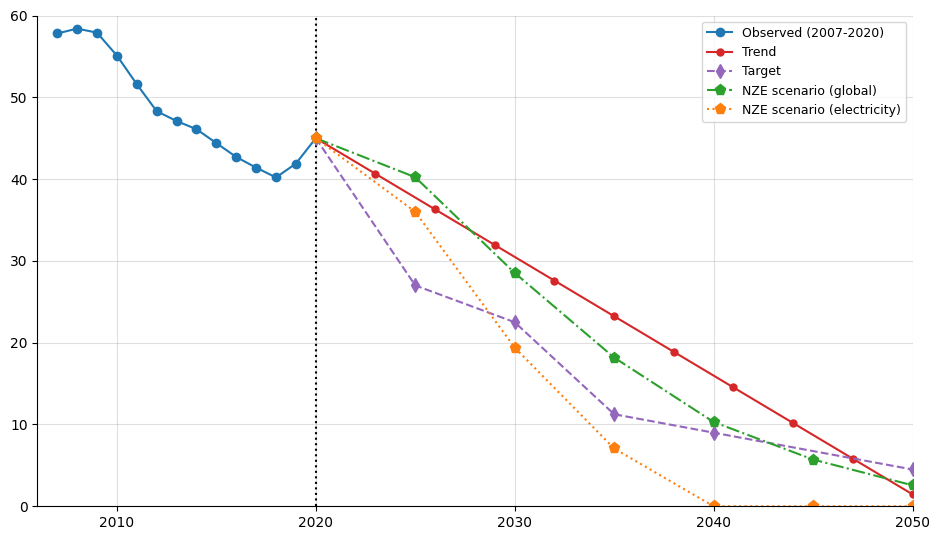

In [3]:
t = np.arange(2007, 2021)
CE = np.array([57.8, 58.4, 57.9, 55.1, 51.6, 48.3, 47.1, 46.1,
               44.4, 42.7, 41.4, 40.2, 41.9, 45.0])
x = np.column_stack([np.ones(len(t)), t])
beta_linear = ols(CE, x).beta
beta_log = ols(np.log(CE), x).beta

target = pd.DataFrame({"year": [2020, 2025, 2030, 2035, 2040, 2050],
                        "reduction": [0.00, 0.40, 0.50, 0.75, 0.80, 0.90]})
scenario = pd.DataFrame({
    "year": [2020, 2025, 2030, 2035, 2040, 2045, 2050],
    "global": [0.000, 0.106, 0.366, 0.596, 0.771, 0.873, 0.943],
    "electricity": [0.000, 0.200, 0.569, 0.843, 1.000, 1.000, 1.000],
})

t0, CE_t0 = 2020, CE[-1]
CE_target = CE_t0 * (1 - target["reduction"])
CE_scenario1 = CE_t0 * (1 - scenario["global"])
CE_scenario2 = CE_t0 * (1 - scenario["electricity"])

t_linear = np.arange(2020, 2055)
CE_linear = CE_t0 + beta_linear[1] * (t_linear - t0)
t_log = t_linear
CE_log = CE_t0 * np.exp(beta_log[1] * (t_log - t0))

fig, ax = plt.subplots(figsize=(9.5, 5.5))
ax.plot(t, CE, "-o", color="tab:blue", markersize=6, linewidth=1.5, label="Observed (2007-2020)")
ax.axvline(2020, linestyle=":", color="black", linewidth=1.5)
ax.plot(t_linear, CE_linear, "o-", color="tab:red", markersize=5, linewidth=1.5, markevery=3, label="Trend")
ax.plot(target["year"], CE_target, "--d", color="tab:purple", markersize=7, linewidth=1.5, label="Target")
ax.plot(scenario["year"], CE_scenario1, "-.p", color="tab:green", markersize=8, linewidth=1.5, label="NZE scenario (global)")
ax.plot(scenario["year"], CE_scenario2, ":p", color="tab:orange", markersize=8, linewidth=1.5, label="NZE scenario (electricity)")
ax.set_xticks(range(2000, 2051, 10)); ax.set_xlim(2006, 2050)
ax.set_ylim(0, 60)
ax.grid(alpha=0.4); ax.spines[["top", "right"]].set_visible(False)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 3. Carbon budget under each pathway (`chap9_carbon_pac3.m`)

The area under each of the five paths from section 2 (trend, log-trend,
target, and the two NZE scenarios), integrated from 2020 to each
milestone year — reusing the same piecewise-linear carbon-budget logic
first built in `09a` (`carbon_budget_piecewise`; now used in 2
notebooks, so promoted to 🟡 in `PACKAGING_CANDIDATES.md`).

In [4]:
def carbon_budget_piecewise(t0, t, t_k, CE_k):
    f = interp1d(t_k, CE_k, kind="linear", fill_value="extrapolate")
    knots_in_range = np.asarray(t_k)[(np.asarray(t_k) > t0) & (np.asarray(t_k) < t)]
    tt = np.unique(np.concatenate([[t0], knots_in_range, [t]]))
    yy = f(tt)
    return np.trapezoid(yy, tt)

milestone_years = [2025, 2030, 2035, 2040, 2045, 2050]
rows = []
for t in milestone_years:
    rows.append({
        "year": t,
        "Trend (linear)": carbon_budget_piecewise(t0, t, t_linear, CE_linear),
        "Trend (log-linear)": carbon_budget_piecewise(t0, t, t_log, CE_log),
        "Target": carbon_budget_piecewise(t0, t, target["year"].values, CE_target.values),
        "NZE (global)": carbon_budget_piecewise(t0, t, scenario["year"].values, CE_scenario1.values),
        "NZE (electricity)": carbon_budget_piecewise(t0, t, scenario["year"].values, CE_scenario2.values),
    })
pd.DataFrame(rows).set_index("year").round(0)

,Trend (linear),Trend (log-linear),Target,NZE (global),NZE (electricity)
year,,,,,
2025,207.0,209.0,180.0,213.0,202.0
2030,377.0,390.0,304.0,385.0,341.0
2035,512.0,546.0,388.0,502.0,407.0
2040,610.0,680.0,439.0,573.0,425.0
2045,671.0,796.0,478.0,613.0,425.0
2050,697.0,896.0,506.0,634.0,425.0


## 4. Participation / ambition / credibility score trajectories (`chap9_carbon_pac4.m`, simplified)

The three PAC/CAT-style scoring dimensions: **participation**
(historical index trajectories, years 1-5, several illustrative
entities), **ambition** (target-vs-scenario index paths, years 6-11),
and **credibility** (whether a trend extrapolated from the historical
period actually lands near the stated target by the scenario horizon).
Reproduced here as three plain line-chart panels rather than the
source's 9-subplot spline-interpolated grid (see the disclosed-
simplification note at the top of this notebook).

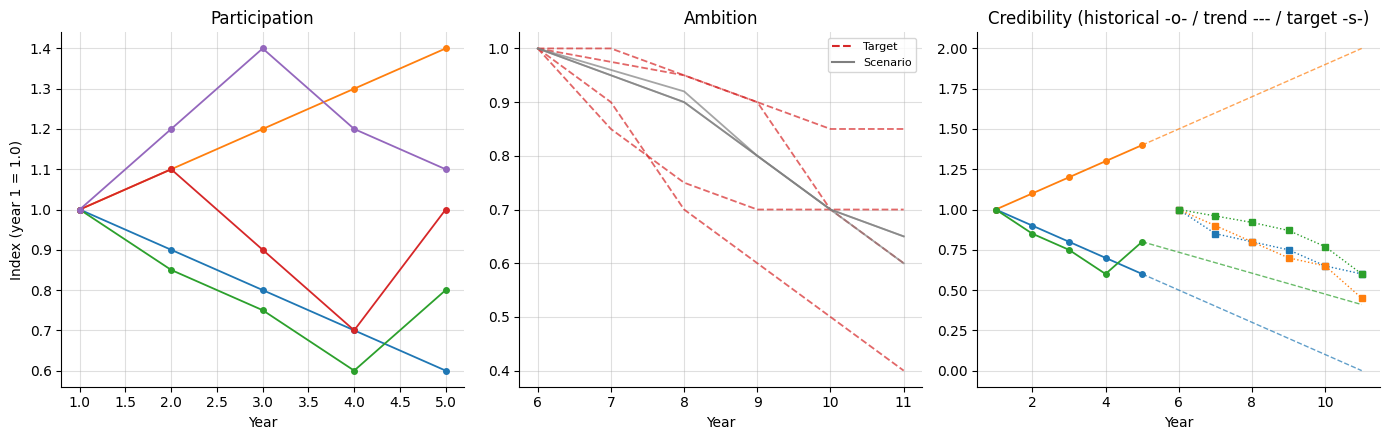

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# Participation: 5 illustrative entities, years 1-5
participation_year = np.array([1, 2, 3, 4, 5])
participation_data = np.array([
    [1.0, 0.9, 0.8, 0.7, 0.6],
    [1.0, 1.1, 1.2, 1.3, 1.4],
    [1.0, 0.85, 0.75, 0.6, 0.8],
    [1.0, 1.1, 0.9, 0.7, 1.0],
    [1.0, 1.2, 1.4, 1.2, 1.1],
]).T
ax = axes[0]
for i in range(participation_data.shape[1]):
    ax.plot(participation_year, participation_data[:, i], "o-", markersize=4, linewidth=1.3)
ax.set_title("Participation"); ax.set_xlabel("Year"); ax.set_ylabel("Index (year 1 = 1.0)")
ax.grid(alpha=0.4); ax.spines[["top", "right"]].set_visible(False)

# Ambition: target vs scenario paths, years 6-11
ambition_year = np.array([6, 7, 8, 9, 10, 11])
ambition_target = np.array([
    [1.0, 0.9, 0.7, 0.6, 0.5, 0.4],
    [1.0, 1.0, 0.95, 0.90, 0.85, 0.85],
    [1.0, 0.85, 0.75, 0.7, 0.7, 0.7],
    [1.0, 0.975, 0.95, 0.9, 0.7, 0.6],
]).T
ambition_scenario = np.array([
    [1.0, 0.95, 0.90, 0.80, 0.70, 0.65],
    [1.0, 0.95, 0.90, 0.80, 0.70, 0.65],
    [1.0, 0.96, 0.92, 0.80, 0.70, 0.60],
]).T
ax = axes[1]
for i in range(ambition_target.shape[1]):
    ax.plot(ambition_year, ambition_target[:, i], "--", color="tab:red", alpha=0.7, linewidth=1.3)
for i in range(ambition_scenario.shape[1]):
    ax.plot(ambition_year, ambition_scenario[:, i], "-", color="tab:gray", alpha=0.7, linewidth=1.3)
ax.plot([], [], "--", color="tab:red", label="Target")
ax.plot([], [], "-", color="tab:gray", label="Scenario")
ax.set_title("Ambition"); ax.set_xlabel("Year")
ax.grid(alpha=0.4); ax.spines[["top", "right"]].set_visible(False)
ax.legend(fontsize=8)

# Credibility: historical (1-5) + trend extrapolation vs target (6-11)
credibility_year1 = np.array([1, 2, 3, 4, 5])
credibility_data1 = participation_data  # same historical series
credibility_year3 = np.array([6, 7, 8, 9, 10, 11])
credibility_target3 = np.array([
    [1.0, 0.85, 0.80, 0.75, 0.65, 0.60],
    [1.0, 0.9, 0.8, 0.7, 0.65, 0.45],
    [1.0, 0.96, 0.92, 0.87, 0.77, 0.6],
]).T
ax = axes[2]
for i in range(3):
    y_hist = credibility_data1[:, i]
    xh = np.column_stack([np.ones(len(credibility_year1)), credibility_year1])
    beta = ols(y_hist, xh).beta
    beta0 = y_hist[-1] - beta[1] * credibility_year1[-1]  # re-anchored to last observed point
    t_trend = np.linspace(credibility_year1[-1], credibility_year3[-1], 50)
    y_trend = beta0 + beta[1] * t_trend
    ax.plot(credibility_year1, y_hist, "o-", color=f"C{i}", markersize=4, linewidth=1.3)
    ax.plot(t_trend, y_trend, "--", color=f"C{i}", linewidth=1.0, alpha=0.7)
    ax.plot(credibility_year3, credibility_target3[:, i], "s:", color=f"C{i}", markersize=4, linewidth=1.0)
ax.set_title("Credibility (historical -o- / trend --- / target -s-)")
ax.set_xlabel("Year")
ax.grid(alpha=0.4); ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

## 5. Archetype profiles: PS/AS/CS score combinations (`chap9_carbon_pac5.m`, simplified)

Four illustrative archetypes built from a Participation Score (PS),
Ambition Score (AS), and Credibility Score (CS): a "model student"
(strong on all three), a "black sheep" (weak on all three), a "shy
child" (participates and is credible but unambitious), and a
"greenwashing" profile (ambitious on paper but weak participation and
credibility). Reproduced as a standard 3-axis radar chart per archetype
rather than the source's polar pie-wedge idiom (see the disclosed-
simplification note at the top of this notebook).

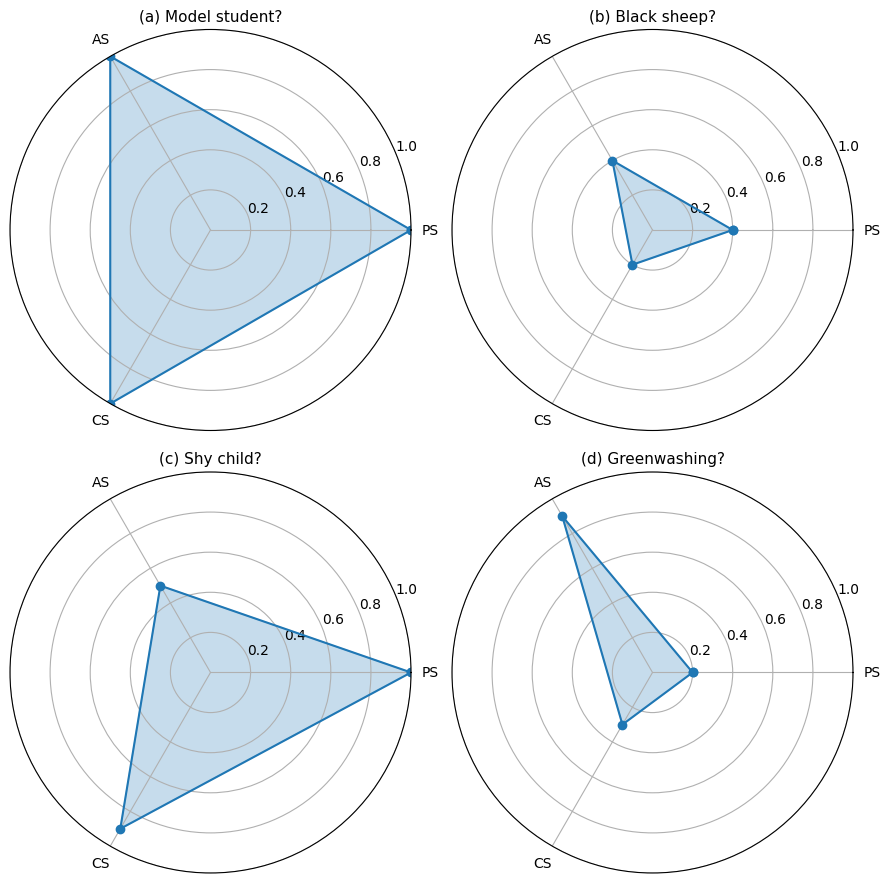

In [6]:
labels = ["PS", "AS", "CS"]
archetypes = {
    "(a) Model student?": [1.00, 0.40, 0.50, 0.90][:3],
    "(b) Black sheep?": [1.00, 0.40, 1.00, 0.20][:3],
    "(c) Shy child?": [1.00, 0.20, 0.90, 0.30][:3],
}
# Source data rows are [AS, PS, CS] per column iter=1..4; reconstructed here as
# {PS, AS, CS} triples per archetype (iter=4, "Greenwashing", reuses column 4).
raw = np.array([
    [1.00, 0.40, 0.50, 0.90],  # AS
    [1.00, 0.40, 1.00, 0.20],  # PS
    [1.00, 0.20, 0.90, 0.30],  # CS
])
archetype_names = ["(a) Model student?", "(b) Black sheep?", "(c) Shy child?", "(d) Greenwashing?"]
data = {name: {"PS": raw[1, i], "AS": raw[0, i], "CS": raw[2, i]} for i, name in enumerate(archetype_names)}

angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(2, 2, figsize=(9, 9), subplot_kw={"projection": "polar"})
for ax, name in zip(axes.flat, archetype_names):
    values = [data[name][k] for k in labels]
    values += values[:1]
    ax.plot(angles, values, "o-", linewidth=1.5, color="tab:blue")
    ax.fill(angles, values, alpha=0.25, color="tab:blue")
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(labels)
    ax.set_ylim(0, 1.0)
    ax.set_title(name, fontsize=11)

plt.tight_layout()
plt.show()

## 6. Addendum: annual carbon-offset market volume (`chap9_carbon_offsetting2.m`)

Illustrative annual voluntary carbon offset volumes (MtCO2e),
2010-2022 — a self-contained script with no natural home in `09a`-`09e`
(discovered only when checking the archive's actual file list, see the
correction note at the top).

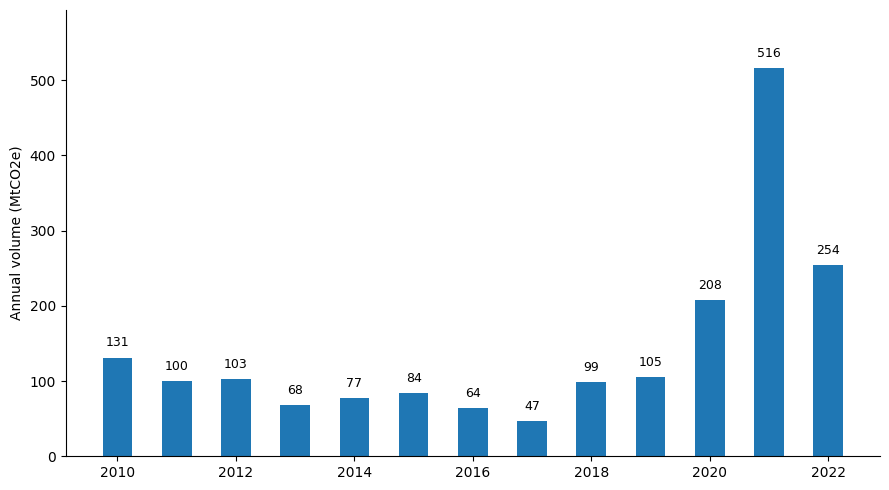

In [7]:
t_off = np.arange(2010, 2023)
volumes = np.array([131, 100, 103, 68, 77, 84, 64, 47, 99, 105, 208, 516, 254])

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(t_off, volumes, width=0.5, color="tab:blue")
for x, v in zip(t_off, volumes):
    ax.text(x, v + 15, str(v), ha="center", fontsize=9)
ax.set_ylabel("Annual volume (MtCO2e)")
ax.set_ylim(0, max(volumes) * 1.15)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 7. Addendum: GHG consolidation approaches (`chap9_consolidation1.m`)

A worked example showing how a group's consolidated Scope 1/2/3
emissions total depends on which GHG Protocol consolidation approach is
used: equity share (partial ownership-weighted), financial control
(fully consolidate anything the parent financially controls), or
operational control (fully consolidate anything the parent operationally
controls). Each row below applies a different ownership/control
percentage to the same seven underlying entities.

In [8]:
CE1 = (827
       + 1.00 * 135 + 0.90 * 261 + 0.45 * 220 + 0 * 1385
       + 0.90 * 0.75 * 63 + 0.90 * 0.50 * 179 + 0.45 * 0.33 * 37)

CE2 = (827
       + 1.00 * 135 + 1.00 * 261 + 1.00 * 220 + 0 * 1385
       + 1.00 * 1.00 * 63 + 1.00 * 0.50 * 179 + 1.00 * 0.00 * 37)

CE3 = (827
       + 1.00 * 135 + 1.00 * 261 + 1.00 * 220 + 0 * 1385
       + 1.00 * 1.00 * 63 + 1.00 * 0.00 * 179 + 1.00 * 0.00 * 37)

pd.DataFrame({
    "Consolidation approach": ["Equity share", "Financial control", "Operational control"],
    "Consolidated CE": [CE1, CE2, CE3],
}).round(2)

,Consolidation approach,Consolidated CE
0,Equity share,1424.47
1,Financial control,1595.50
2,Operational control,1506.00


## 8. Addendum: Green Revenue Share (`chap9_greenness_grs1.m`)

A small worked example of the Green Revenue Share (GRS) metric — the
fraction of total revenue coming from activities classified as "green"
— computed two ways depending on which revenue lines count as green.

In [9]:
TR = 103 + 256 + 89 + 174 + 218
GR1 = 103 + 89 + 218
GRS1 = GR1 / TR
GR2 = 103 + 89
GRS2 = GR2 / TR

pd.DataFrame({
    "Quantity": ["Total revenue (TR)", "Green revenue, definition 1 (GR1)", "GRS1 = GR1/TR",
                 "Green revenue, definition 2 (GR2)", "GRS2 = GR2/TR"],
    "Value": [TR, GR1, round(GRS1, 4), GR2, round(GRS2, 4)],
})

,Quantity,Value
0,Total revenue (TR),840.0000
1,"Green revenue, definition 1 (GR1)",410.0000
2,GRS1 = GR1/TR,0.4881
3,"Green revenue, definition 2 (GR2)",192.0000
4,GRS2 = GR2/TR,0.2286
